<a href="https://colab.research.google.com/github/VSShu25/ML-Basic/blob/main/homework_09/homework_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Часть 1. EDA

---



Будем работать с датасетом по ссылке https://www.kaggle.com/uciml/breast-cancer-wisconsin-data

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
dataPath = '/content/drive/My Drive/datasets/data.csv'

# Download latest version
#path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
#print("Path to dataset files:", path)

Mounted at /content/drive


In [ ]:
df = pd.read_csv(dataPath)
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

Размер датасета: (569, 33)

Первые 5 строк:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_wo

Посмотрите на базовые статистики датасета: средние, медианы и т.д.

In [ ]:
# базовые статистики: среднее, медиана, стандартное отклонение и т. д.
basic_stats = df.describe()
print("\n\n\nБазовые статистики:\n", basic_stats)

# медианы
medians = df.median(numeric_only=True)
print("\n\n\nМедианы:\n", medians)




Базовые статистики:
                  id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.01406

Постройте гистограммы/распределения признаков, при этом используйте целевую переменную, чтобы сгруппировать и раскрасить гистограммы.

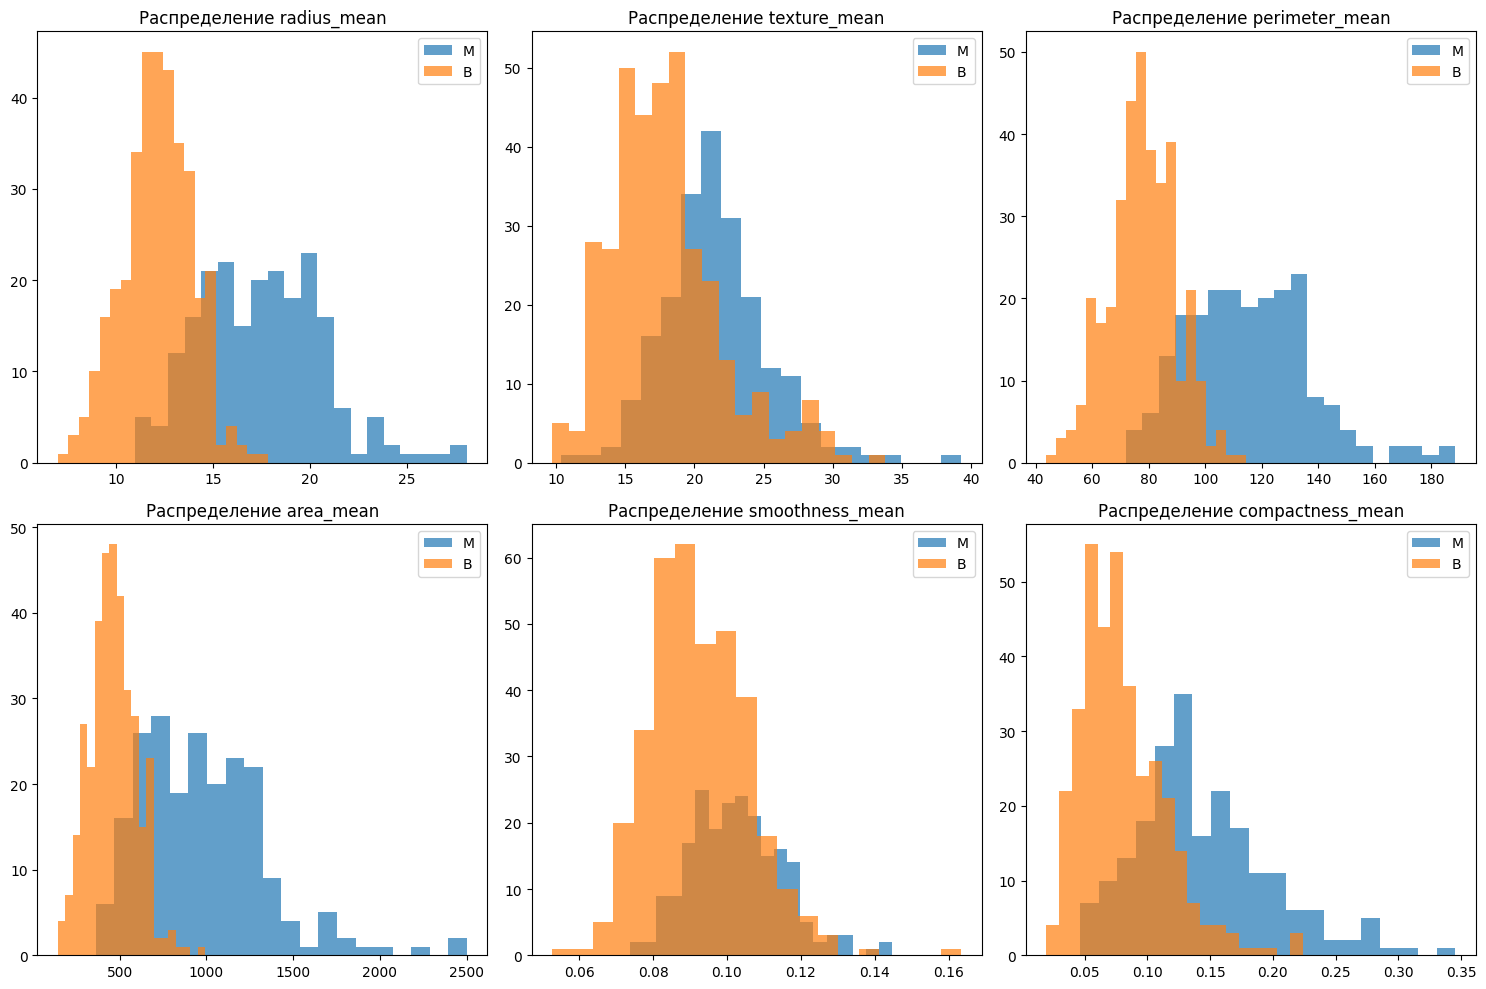

In [ ]:
# целевая переменная — 'diagnosis'
target = 'diagnosis'
features = df.columns.drop(target)

# гистограммы
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(features[1:7]):
    for diagnosis in df[target].unique():
        subset = df[df[target] == diagnosis][feature]
        axes[i].hist(subset, alpha=0.7, label=diagnosis, bins=20)
    axes[i].set_title(f'Распределение {feature}')
    axes[i].legend()

plt.tight_layout()
plt.show()

Постройте heatmap для матрицы корреляций, есть ли признаки, которые сильно скоррелированы? Какие это признаки?

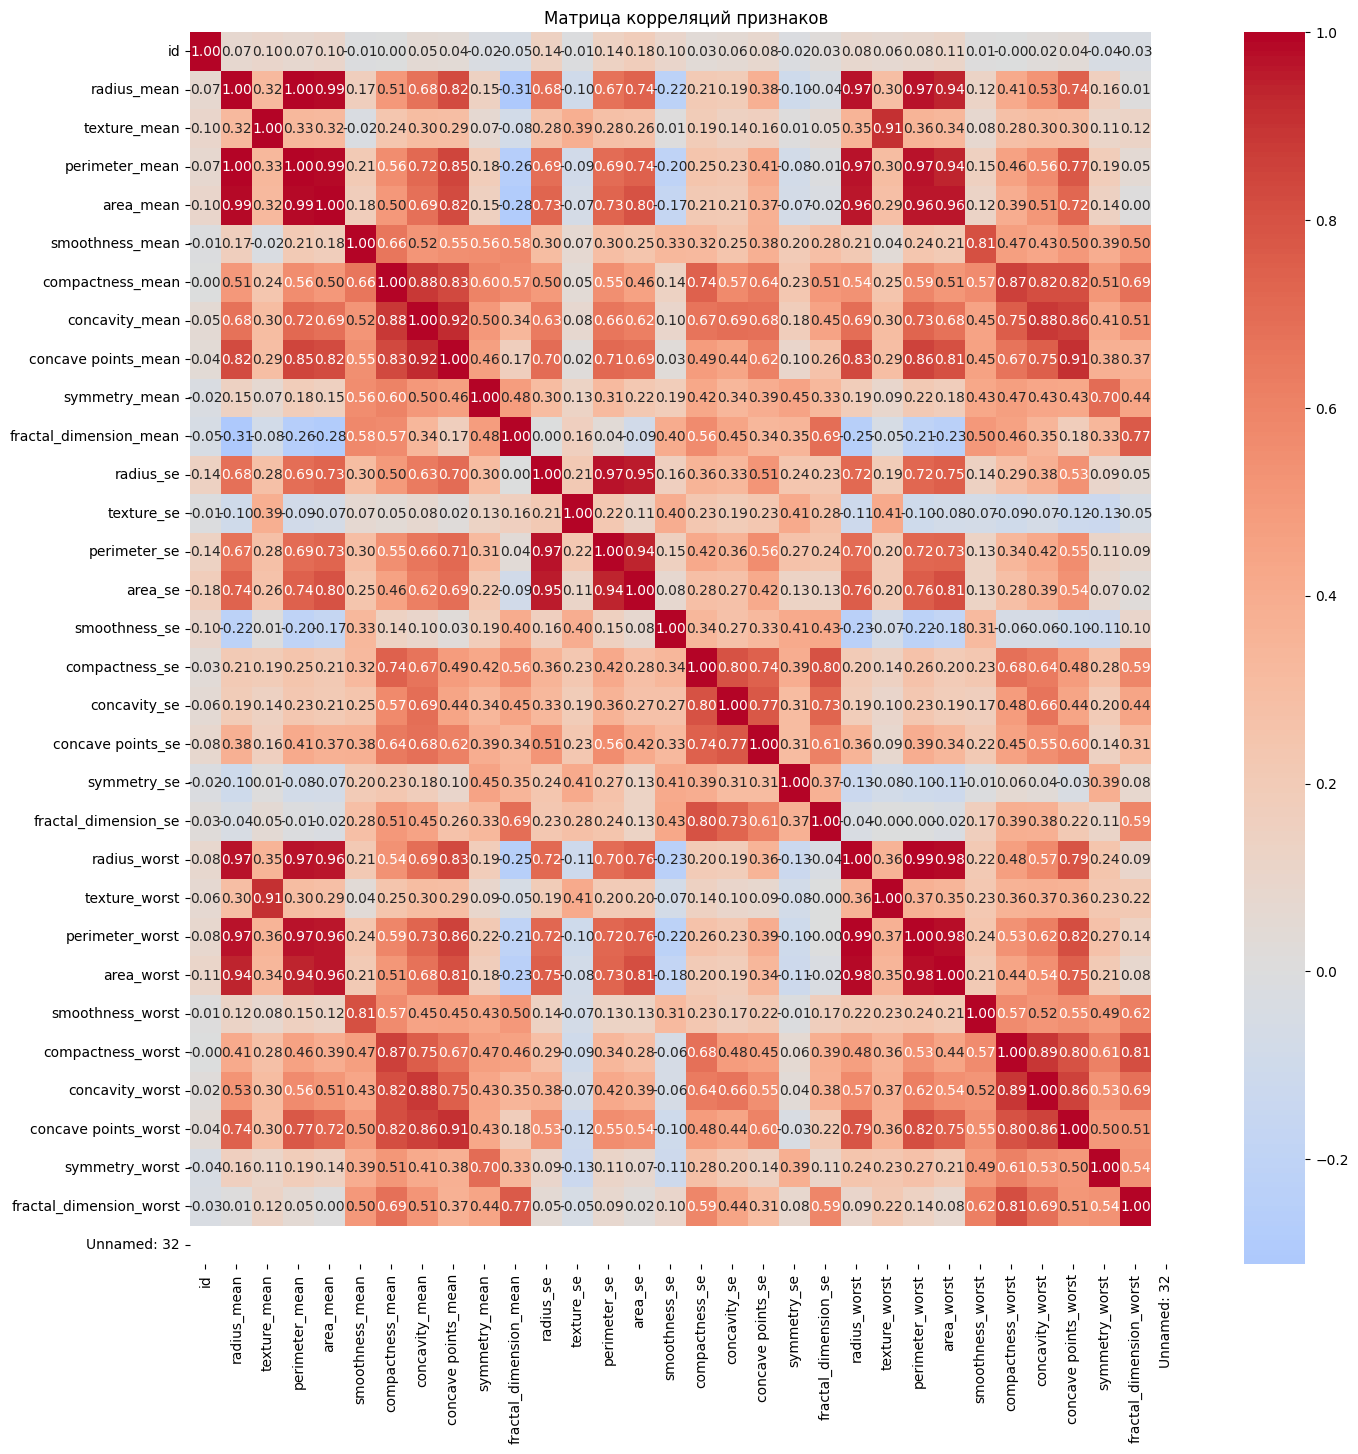

Сильно скоррелированные пары |r| > 0.8 :
radius_mean — perimeter_mean: r = 0.998
radius_mean — area_mean: r = 0.987
radius_mean — concave points_mean: r = 0.823
radius_mean — radius_worst: r = 0.970
radius_mean — perimeter_worst: r = 0.965
radius_mean — area_worst: r = 0.941
texture_mean — texture_worst: r = 0.912
perimeter_mean — area_mean: r = 0.987
perimeter_mean — concave points_mean: r = 0.851
perimeter_mean — radius_worst: r = 0.969
perimeter_mean — perimeter_worst: r = 0.970
perimeter_mean — area_worst: r = 0.942
area_mean — concave points_mean: r = 0.823
area_mean — area_se: r = 0.800
area_mean — radius_worst: r = 0.963
area_mean — perimeter_worst: r = 0.959
area_mean — area_worst: r = 0.959
smoothness_mean — smoothness_worst: r = 0.805
compactness_mean — concavity_mean: r = 0.883
compactness_mean — concave points_mean: r = 0.831
compactness_mean — compactness_worst: r = 0.866
compactness_mean — concavity_worst: r = 0.816
compactness_mean — concave points_worst: r = 0.816
conca

In [ ]:
# матрица корреляций
correlation_matrix = df.corr(numeric_only=True)

# Замена M/B на числовые значения для лучшей визуализации
df = pd.read_csv((dataPath))
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# визуализация
plt.figure(figsize=(16, 16))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Матрица корреляций признаков')
plt.show()

# сильно скоррелированные признаки |r| > 0.8
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.8:
            high_corr.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_value))

print("Сильно скоррелированные пары |r| > 0.8 :")
for pair in high_corr:
    print(f"{pair[0]} — {pair[1]}: r = {pair[2]:.3f}")

Анализ матрицы корреляции показывает, что есть достаточно много скоррелированных признаков.
Признаки, описывающие размер и форму (радиус, периметр, площадь), сильно коррелируют как внутри групп «mean» и «worst», так и между ними. Это говорит о том, что они несут схожую информацию.
Признаки, характеризующие вогнутость и компактность, также демонстрируют высокую взаимную корреляцию, что указывает на их общую природу.
Наличие множества пар с r>0,9 говорит о высокой избыточности данных.


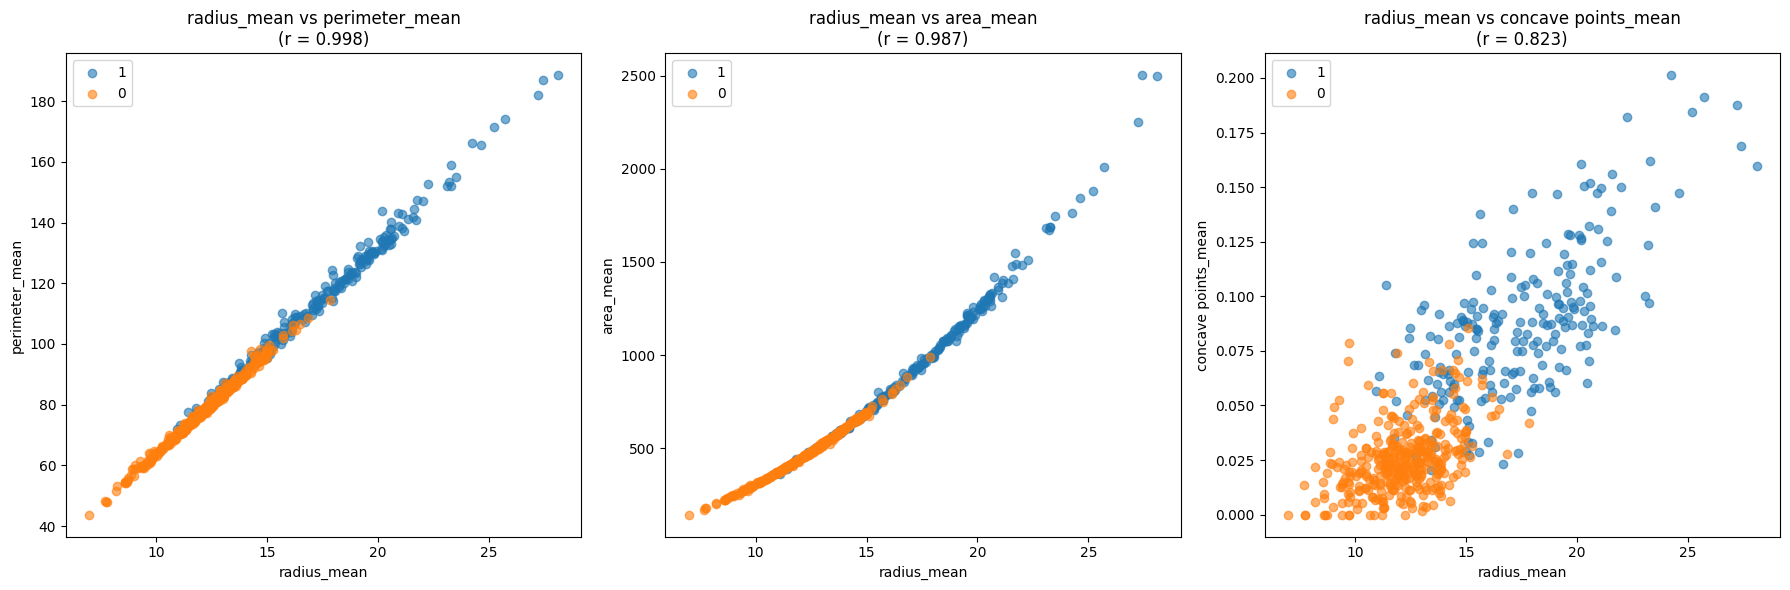

In [ ]:
# первые 3 сильно скоррелированные пары
pairs_to_plot = high_corr[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.ravel()

for idx, (feat1, feat2, corr) in enumerate(pairs_to_plot):
    for diagnosis in df[target].unique():
        subset = df[df[target] == diagnosis]
        axes[idx].scatter(subset[feat1], subset[feat2], alpha=0.6, label=diagnosis)
    axes[idx].set_xlabel(feat1)
    axes[idx].set_ylabel(feat2)
    axes[idx].set_title(f'{feat1} vs {feat2}\n(r = {corr:.3f})')
    axes[idx].legend()

plt.tight_layout()
plt.show()

Используя boxplots и группировку по целевой переменной, попробуйте предположить, по каким признакам наиболее удобно было бы отделить злокачественные новообразования от доброкачественных.


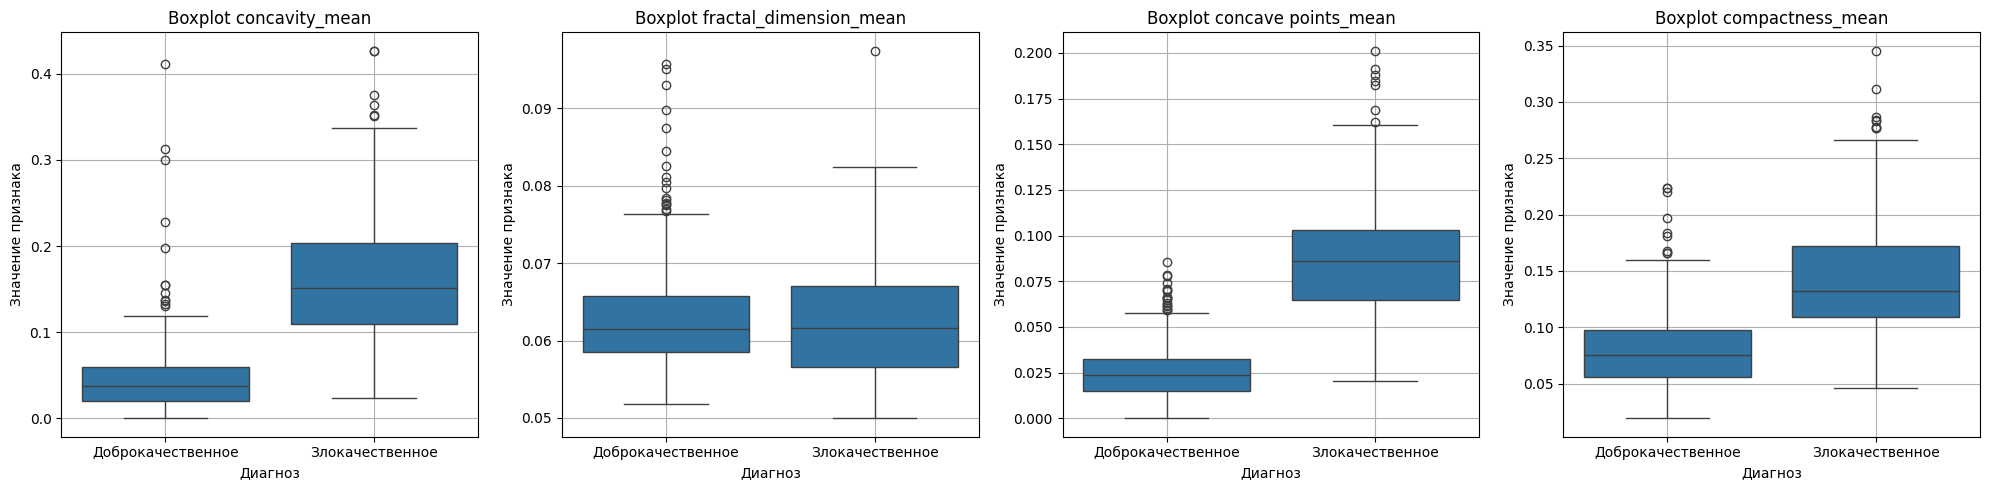

In [ ]:
# Замена M/B на числовые значения для лучшей визуализации
df = pd.read_csv((dataPath))
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})


# несколько ключевых признаков для анализа
key_features = ['concavity_mean', 'fractal_dimension_mean', 'concave points_mean', 'compactness_mean']

# Проверка наличия пропусков и их удаление для выбранных признаков
df_clean = df[key_features + ['diagnosis']].dropna()

'''
# Проверка пропусков
print("\nКоличество пропусков в выбранных столбцах:")
print(df[key_features + ['diagnosis']].isnull().sum())

# Проверка после очистки
df_clean = df[key_features + ['diagnosis']].dropna()
print(f"\nРазмер очищенного датафрейма: {df_clean.shape}")
if df_clean.empty:
    print("Датафрейм пуст — проверьте пропуски и корректность имён столбцов!")
else:
    print("Уникальные значения в 'diagnosis':", df_clean['diagnosis'].unique())
    print("Статистика по признакам:")
    print(df_clean[key_features].describe())
'''


# Настройка размера графика
plt.figure(figsize=(20, 5))

# Создание boxplot для каждого признака
for i, feature in enumerate(key_features, 1):
    plt.subplot(1, 4, i)  # 1 строка, 4 столбца
    sns.boxplot( x='diagnosis', y=feature, data=df_clean)
    plt.title(f'Boxplot {feature}')
    plt.xticks([0, 1], ['Доброкачественное', 'Злокачественное'])
    plt.xlabel('Диагноз')
    plt.ylabel('Значение признака')
    plt.grid(True)

plt.tight_layout()
plt.show()

Перебрав разные результаты визуализации, предположу, что для предсказания диагноза полезно будет учесть следующие признаки: radius_mean, texture_mean, concave points_mean, perimeter_mean, compactness_mean.



Метрики качества базовой модели:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       108
           1       0.90      0.89      0.90        63

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171


Метрики качества оптимизированной модели:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       108
           1       0.97      0.89      0.93        63

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171

Лучшая метрика AUC: 0.9905937683715461

Оптимальное количество соседей: 23

Исходное количество строк: 569
Количество строк после очистки: 569
Удалено пропусков: 0


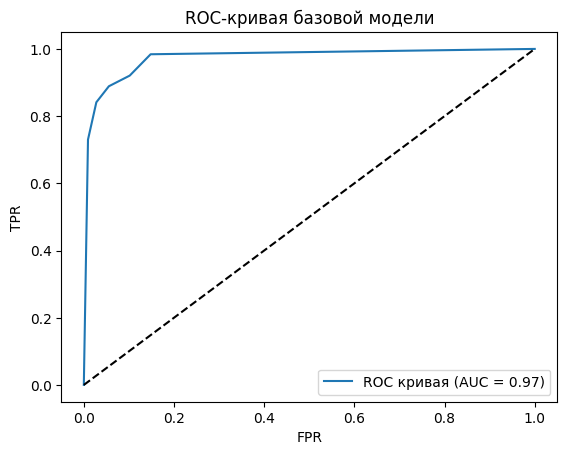

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV

df = pd.read_csv(dataPath) # считываю еще раз

# только нужные признаки
selected_features = ['radius_mean', 'texture_mean', 'concave points_mean', 'perimeter_mean', 'compactness_mean']

# пропуски по целевой переменной и соответствующим признакам
df_clean = df.dropna(subset=['diagnosis'] + selected_features)
X = df_clean[selected_features]
y = df_clean['diagnosis'].map({'M': 1, 'B': 0})


# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Стандартизация необходима, так как kNN чувствителен к масштабу признаков
# Разные признаки имеют разный диапазон значений, что может исказить результаты
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Базовая модель kNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Оценка качества базовой модели
print("\nМетрики качества базовой модели:")
print(classification_report(y_test, y_pred))

# ROC-кривая и AUC
fpr, tpr, thresholds = roc_curve(y_test, knn.predict_proba(X_test_scaled)[:, 1])
roc_auc = roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label=f'ROC кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Линия случайного классификатора
plt.title('ROC-кривая базовой модели')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

# Настройка гиперпараметров
param_grid = {'n_neighbors': np.arange(1, 31)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

# Лучшая модель
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)

print("\nМетрики качества оптимизированной модели:")
print(classification_report(y_test, y_pred_best))
print(f"Лучшая метрика AUC: {roc_auc_score(y_test, best_knn.predict_proba(X_test_scaled)[:, 1])}")

# Вывод оптимальных параметров
print(f"\nОптимальное количество соседей: {grid.best_params_['n_neighbors']}")

# Проверка количества удаленных пропусков
print(f"\nИсходное количество строк: {len(df)}")
print(f"Количество строк после очистки: {len(df_clean)}")
print(f"Удалено пропусков: {len(df) - len(df_clean)}")